In [ ]:
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("DESeq2", update=FALSE, ask=FALSE)

install.packages("pheatmap")

In [ ]:
library(DESeq2)
library(pheatmap)

# Importing the data (file name: "GSE178878_raw.txt.gz")
counts_data <- read.table("GSE178878_raw.txt.gz", header=TRUE, sep="\t", row.names=1)

head(counts_data)

In [ ]:
# List of hearts used in the experiment
colnames(counts_data)

In [ ]:
# List of genes detected in the experiment
rownames(counts_data)

In [ ]:
# Looking whether Trim63 and Foxo1 were actually detected in the tissue sample
"Trim63" %in% rownames(counts_data)
"Foxo1" %in% rownames(counts_data)

In [ ]:
# Getting the column names (heart names) from the data
heart_samples <- colnames(counts_data)

# Sorting the hearts for their specific Age group and Status
age_vector <- c(
    "Aged", "Aged", "Aged", "Aged", "Young", "Young", "Young", "Young", 
    "Young", "Young", "Young", "Young", "Young", "Young", "Aged", "Aged", 
    "Aged", "Aged", "Young", "Young", "Young", "Aged", "Aged", "Aged"
)

status_vector <- c(
    "Surviving", "Surviving", "Dying", "Dying", "Dying", "Surviving", 
    "Dying", "Surviving", "Surviving", "Surviving", "Surviving", "Dying", 
    "Dying", "Dying", "Dying", "Dying", "Surviving", "Surviving", 
    "Uninfected", "Uninfected", "Uninfected", "Uninfected", "Uninfected", "Uninfected"
)

In [ ]:
col_data <- data.frame(
    SampleID = heart_samples,
    Age = age_vector,
    Status = status_vector
)

rownames(col_data) <- col_data$SampleID

print(col_data)

In [ ]:
# Initialising DESeq2
dds <- DESeqDataSetFromMatrix(countData = counts_data,
                              colData = col_data,
                              design = ~ Age + Status)

# Normalising the data
vsd <- vst(dds, blind=FALSE)
vst_mat <- assay(vsd)

# Defining selected genes
sanchez_gene <- c("Foxo1", "Trim63", "Rps17", "Map1lc3b")

filtered_matrix <- vst_mat[rownames(vst_mat) %in% sanchez_gene, ]

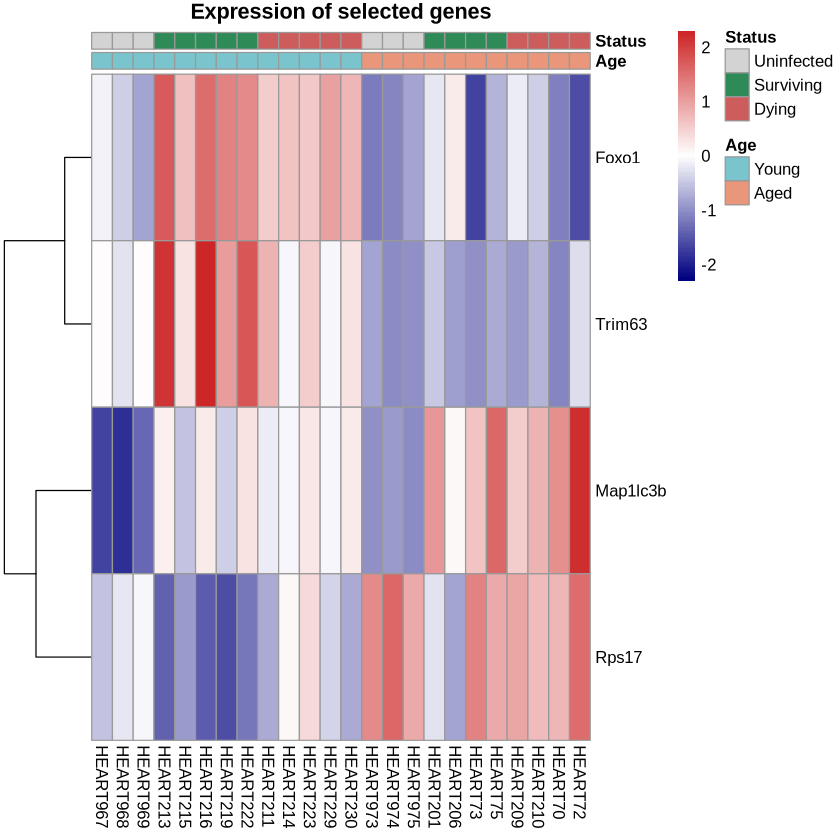

In [13]:
# Using Combined Groups to sort the data
col_data(se)$CombinedGroup <- paste(col_data$Age, col_data$Status, sep = "-")

# Defining the sub-groups
g1 <- subset(col_data, CombinedGroup == "Aged-Uninfected")
g2 <- subset(col_data, CombinedGroup == "Aged-Surviving")
g3 <- subset(col_data, CombinedGroup == "Aged-Dying")
g4 <- subset(col_data, CombinedGroup == "Young-Uninfected")
g5 <- subset(col_data, CombinedGroup == "Young-Surviving")
g6 <- subset(col_data, CombinedGroup == "Young-Dying")

# Defining the order in the heatmap
col_data_sorted <- rbind(g4, g5, g6, g1, g2, g3)

# Sorting the rows
matrix_sorted <- filtered_matrix[, rownames(col_data_sorted)]

annotation_colors <- list(
  Age = c(Young = "#7ac5cd", Aged = "#e9967a"),                     # Light blue and light red
  Status = c(Uninfected = "#d3d3d3", Surviving = "#2e8b57", Dying = "#cd5c5c") # Grey, Green, Red
)

# Plotting the heatmap
pheatmap(matrix_sorted,
         scale = "row",
         cluster_rows = TRUE,         
         cluster_cols = FALSE,        
         annotation_col = col_data_sorted[c("Age", "Status")],
         annotation_colors = annotation_colors,
         color = colorRampPalette(c("navy", "white", "firebrick3"))(100),
         main = "Expression of selected genes")